In [2]:
## necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# packages for OLS
import statsmodels.api as sm
# packages for Lasso and Ridge
from sklearn.linear_model import Lasso, Ridge
# packages for cross validation
from sklearn.model_selection import train_test_split, cross_val_score
# packages for evaluation metrics


In [3]:
!pip install openpyxl

In [4]:
import pmdarima as pm

### Data importing and Cleaning

In [5]:
# read data
data1 = pd.read_excel("/Users/geoffpoint-du-jour/Downloads/Forecasting/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx")
loandata = pd.read_csv("BUSLOANS.CSV")
cpi = pd.read_csv("CPI.csv")
unemployment = pd.read_csv("UNEMPLOYMENT.csv")

In [6]:
data1.describe()

,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
count,174119.000000,17766.000000,17766.000000,17766.000000,17766.000000,173593.000000,17766.000000,17766.000000,17766.000000,17766.000000,...,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000
mean,95.236762,840.967060,866.092443,891.087843,917.006110,108.933840,969.639685,996.338306,1022.676059,1049.292877,...,3127.281510,3163.518732,3201.570250,3242.751005,3285.449618,3328.596394,3370.754859,3412.454024,3452.267658,3489.628947
std,2289.750694,7307.534944,7535.206910,7761.007686,7993.573881,2665.725873,8463.375885,8700.701152,8934.736738,9170.846646,...,27268.459557,27585.451116,27917.904010,28276.030559,28646.450299,29020.727551,29387.234932,29750.197432,30098.085245,30426.271405
min,-943.333400,-2.092654,-4.364267,-6.741271,-8.660476,-943.333400,-12.707780,-14.835680,-16.965630,-19.100350,...,-81.798450,-82.253550,-82.752540,-83.052440,-83.340140,-83.636070,-83.953930,-84.303440,-84.606930,-84.979890
25%,0.000000,-0.579394,-1.145731,-1.713888,-2.196124,0.000000,-3.080627,-3.466194,-3.909014,-4.286945,...,-9.865396,-9.981096,-10.022375,-9.967483,-9.885205,-9.745334,-9.670343,-9.572050,-9.547108,-9.553268
50%,0.006200,3.551642,4.440057,5.378792,5.805345,0.009100,6.611908,7.486106,8.135852,8.551282,...,27.193900,27.320940,27.527850,27.673905,27.654960,27.789595,27.983630,28.079895,28.304590,28.493520
75%,0.353400,164.802850,169.163125,163.364550,168.849250,0.442900,185.604725,192.341550,199.239550,209.005275,...,821.159900,828.797350,841.240500,855.047225,864.447725,875.365525,882.492400,892.358800,899.330625,903.313425
max,114983.700000,119390.500000,123735.100000,128030.200000,132300.000000,136556.300000,141062.500000,145617.200000,150189.600000,154795.100000,...,518460.000000,525323.000000,532328.200000,539488.600000,546723.000000,553987.700000,561212.700000,568369.900000,575400.300000,582255.800000


In [7]:
loandata.tail() # data is 1947 to present

,observation_date,BUSLOANS
944,2025-09-01,2693.7380
945,2025-10-01,2692.3125
946,2025-11-01,2698.5199
947,2025-12-01,2709.2908
948,2026-01-01,2743.0472


In [8]:
# take a look into unemploymenbt
unemployment.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [9]:
# do a regression with loandata as the dependent variable and unemployment as the independent variable
# merge the two datasets on the date column
# convert date columns to datetime
loandata['Date'] = pd.to_datetime(loandata['observation_date'])
unemployment['Date'] = pd.to_datetime(unemployment['observation_date'])
# merge datasets
merged_data = pd.merge(loandata, unemployment, on='observation_date', how='inner')
# check the merged data
merged_data.head()


,observation_date,BUSLOANS,Date_x,UNRATE,Date_y
0,1948-01-01,14.4049,1948-01-01,3.4,1948-01-01
1,1948-02-01,14.5635,1948-02-01,3.8,1948-02-01
2,1948-03-01,14.7454,1948-03-01,4.0,1948-03-01
3,1948-04-01,14.9301,1948-04-01,3.9,1948-04-01
4,1948-05-01,15.0976,1948-05-01,3.5,1948-05-01


In [10]:
## read NiGEM data
nigem = pd.read_excel("NiGEM_data.xlsx")

In [11]:
nigem['Region'].unique()

array(['NiGEM NGFS v1.24.2|Africa', 'NiGEM NGFS v1.24.2|Argentina',
       'NiGEM NGFS v1.24.2|Asia', 'NiGEM NGFS v1.24.2|Australia',
       'NiGEM NGFS v1.24.2|Austria', 'NiGEM NGFS v1.24.2|Belgium',
       'NiGEM NGFS v1.24.2|Brazil', 'NiGEM NGFS v1.24.2|Bulgaria',
       'NiGEM NGFS v1.24.2|Canada', 'NiGEM NGFS v1.24.2|Chile',
       'NiGEM NGFS v1.24.2|China', 'NiGEM NGFS v1.24.2|Croatia',
       'NiGEM NGFS v1.24.2|Czech Republic', 'NiGEM NGFS v1.24.2|Denmark',
       'NiGEM NGFS v1.24.2|Developing Europe', 'NiGEM NGFS v1.24.2|Egypt',
       'NiGEM NGFS v1.24.2|Estonia', 'NiGEM NGFS v1.24.2|Europe',
       'NiGEM NGFS v1.24.2|Finland', 'NiGEM NGFS v1.24.2|France',
       'NiGEM NGFS v1.24.2|Germany', 'NiGEM NGFS v1.24.2|Greece',
       'NiGEM NGFS v1.24.2|Hong Kong', 'NiGEM NGFS v1.24.2|Hungary',
       'NiGEM NGFS v1.24.2|India', 'NiGEM NGFS v1.24.2|Indonesia',
       'NiGEM NGFS v1.24.2|Ireland', 'NiGEM NGFS v1.24.2|Italy',
       'NiGEM NGFS v1.24.2|Japan', 'NiGEM NGFS v1.24.2|

In [12]:
nigem.head()
## filter Region for United States
nigem = nigem[nigem['Region'] == 'NiGEM NGFS v1.24.2|United States']

In [13]:
nigem["Variable"].unique()

array(['Carbon pricing ; $ per Tn CO2(combined(no bus))',
       'Carbon pricing ; $ per Tn CO2(combined)',
       'Carbon pricing ; $ per Tn CO2(physical)',
       'Carbon pricing ; $ per Tn CO2(transition)',
       'Central bank Intervention rate (policy interest rate) ; %(combined(no bus))',
       'Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Central bank Intervention rate (policy interest rate) ; %(physical)',
       'Central bank Intervention rate (policy interest rate) ; %(transition)',
       'Coal price ; US$ per barrel (equiv)(combined(no bus))',
       'Coal price ; US$ per barrel (equiv)(combined)',
       'Coal price ; US$ per barrel (equiv)(physical)',
       'Coal price ; US$ per barrel (equiv)(transition)',
       'Consumption (private)(combined(no bus))',
       'Consumption (private)(combined)',
       'Consumption (private)(physical)',
       'Consumption (private)(transition)',
       'Domestic demand(combined(no bus))', 'Domestic de

In [14]:
## filter Variable column for any variable that contains combined
nigem = nigem[nigem['Variable'].str.contains('combined', case=False, na=False)]
nigem.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 6772 to 100656
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Model     756 non-null    object 
 1   Scenario  756 non-null    object 
 2   Region    756 non-null    object 
 3   Variable  756 non-null    object 
 4   Unit      756 non-null    object 
 5   2022      756 non-null    float64
 6   2023      756 non-null    float64
 7   2024      756 non-null    float64
 8   2025      756 non-null    float64
 9   2026      756 non-null    float64
 10  2027      756 non-null    float64
 11  2028      756 non-null    float64
 12  2029      756 non-null    float64
 13  2030      756 non-null    float64
 14  2031      756 non-null    float64
 15  2032      756 non-null    float64
 16  2033      756 non-null    float64
 17  2034      756 non-null    float64
 18  2035      756 non-null    float64
 19  2036      756 non-null    float64
 20  2037      756 non-null    float

In [15]:
## standardize frequency of all data to quarterly


## Data analysis

In [16]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [17]:
ngfs_quarterly.head()

,Below 2°C_Carbon pricing ; $ per Tn CO2(combined),Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined),Below 2°C_Coal price ; US$ per barrel (equiv)(combined),Below 2°C_Consumption (private)(combined),Below 2°C_Domestic demand(combined),Below 2°C_Effective exchange rate(combined),Below 2°C_Energy consumption (total) ; MnToe(combined),Below 2°C_Equity prices(combined),Below 2°C_Exports (goods and services)(combined),Below 2°C_Gas price ; US$ per barrel (equiv)(combined),...,Net Zero 2050_Productivity (output per hour worked); US$ Bn(combined),Net Zero 2050_Quarterly consumption of coal ; MnToe(combined),Net Zero 2050_Quarterly consumption of gas ; MnToe(combined),Net Zero 2050_Quarterly consumption of non-carbon ; MnToe(combined),Net Zero 2050_Quarterly consumption of oil ; MnToe(combined),Net Zero 2050_Real personal disposable income(combined),Net Zero 2050_Revenue from CB or BCA tax; US$ Bn(combined),Net Zero 2050_Trend output for capacity utilisation(combined),Net Zero 2050_Unemployment rate ; %(combined),Net Zero 2050_Volume energy use as a share of GDP ; Bn US$(PPP)(combined)
Year,,,,,,,,,,,,,,,,,,,,,
2022-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-03-31,1.908148,0.090281,1.003075,-0.339661,-0.343849,-0.146234,-0.164327,-0.939242,0.048806,0.283405,...,-0.359681,-0.879059,-0.340875,0.363506,-0.441451,-0.435026,68.850639,-0.318989,-0.011146,-0.191943
2023-06-30,3.816295,0.180562,2.006149,-0.679322,-0.687699,-0.292468,-0.328655,-1.878484,0.097611,0.566809,...,-0.719362,-1.758118,-0.681750,0.727011,-0.882901,-0.870052,137.701278,-0.637978,-0.022293,-0.383887
2023-09-30,5.724443,0.270843,3.009224,-1.018983,-1.031548,-0.438701,-0.492982,-2.817726,0.146417,0.850214,...,-1.079044,-2.637178,-1.022625,1.090517,-1.324352,-1.305078,206.551917,-0.956967,-0.033439,-0.575830
2023-12-31,7.632591,0.361124,4.012299,-1.358644,-1.375397,-0.584935,-0.657310,-3.756967,0.195222,1.133619,...,-1.438725,-3.516237,-1.363500,1.454023,-1.765802,-1.740103,275.402556,-1.275956,-0.044585,-0.767774


### Model with NGFS scenario data

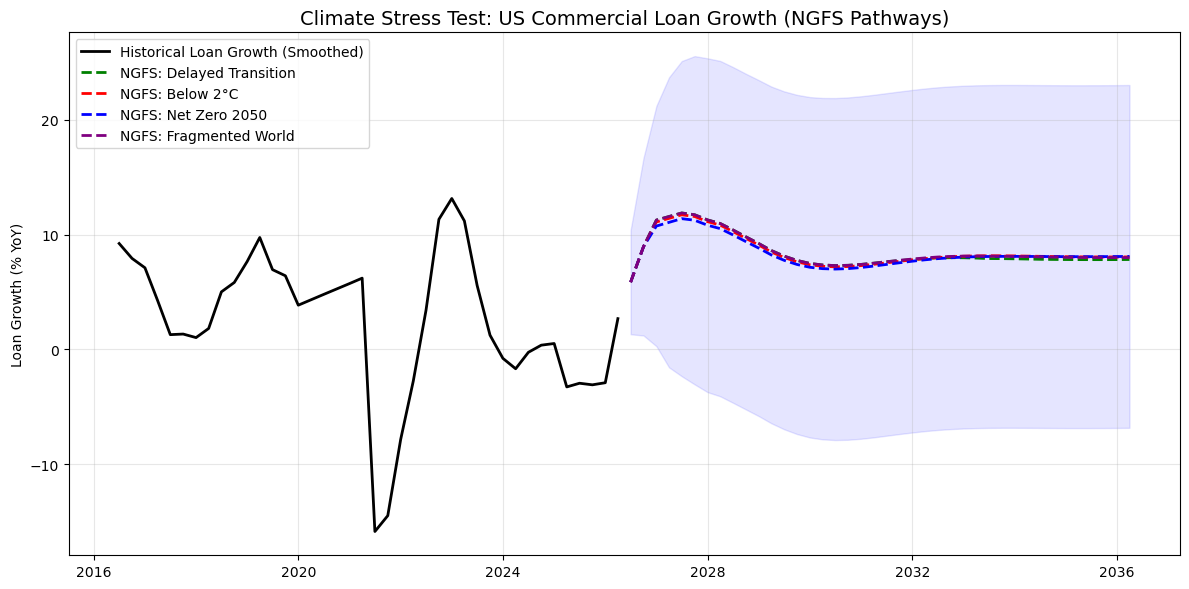

In [63]:
## THIS IS THE FINAL MODEL WITH NGFS SCENARIOS INTEGRATED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. & 2. (Kept your cleaning/loading logic)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        return pd.DataFrame()

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# 3. Smoothing (Kept your logic)
shock_start, shock_end = '2020-03-01', '2020-12-31'
df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate(method='linear')
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear')

# 4. Feature Engineering
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)
df_train = df_history.dropna()

# 5. Train Model (Optimal ARIMA 2,0,2)
y = df_train['Loan_Growth']
X = df_train[['Unemployment_Lag2']]
model = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4)) 
model_fit = model.fit()

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS (Updated to use actual NGFS Data)
# ---------------------------------------------------------
forecast_steps = 40 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='QE')[1:]
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]

# NECESSARY CHANGE: Use NGFS Shocks instead of np.linspace
def build_ngfs_exog(scenario_prefix):
    # Find column
    col = [c for c in ngfs_quarterly.columns if scenario_prefix in c and "Unemployment" in c][0]
    shocks = ngfs_quarterly.loc[forecast_dates[0]:, col].head(forecast_steps)
    # Anchor to history
    future_path = last_actual_unemp + shocks
    # Combine & Lag
    full_series = pd.concat([df_history['Unemployment_Rate'], future_path])
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag2'] = full_series.shift(2).loc[forecast_dates]
    return X_f

X_future_delayed = build_ngfs_exog('Delayed transition')
X_future_stress = build_ngfs_exog('Below 2°C')
X_future_nz = build_ngfs_exog('Net Zero 2050')
X_future_fragmented = build_ngfs_exog('Fragmented World')

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
# Run all 3 scenarios through the model
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_nz = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
p_nz = forecast_nz.predicted_mean
conf_nz = forecast_nz.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=forecast_steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
conf_fragmented = forecast_fragmented.conf_int()


# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))


# Plot History
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)

# NGFS Scenarios
plt.plot(pred_delayed.index, pred_delayed, 
         label='NGFS: Delayed Transition', color='green', linestyle='--', linewidth=2)

plt.plot(pred_stress.index, pred_stress, 
         label='NGFS: Below 2°C', color='red', linestyle='--', linewidth=2)

plt.plot(p_nz.index, p_nz, 
         label='NGFS: Net Zero 2050', color='blue', linestyle='--', linewidth=2)
plt.plot(pred_fragmented.index, pred_fragmented,
         label='NGFS: Fragmented World', color='purple', linestyle='--', linewidth=2)
# Shading for the Net Zero Scenario
plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)

plt.title('Climate Stress Test: US Commercial Loan Growth (NGFS Pathways)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##USING THIS MODEL 

In [ ]:
# 1. Feature Engineering: Calculate Inflation from CPI
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100

# 2. Apply the Lag (Lag 2 to match Unemployment)
df_history['Inflation_Lag2'] = df_history['Inflation'].shift(2)

# 3. Drop NaNs and define the new feature list
df_train = df_history.dropna()
features = ['Unemployment_Lag2', 'Inflation_Lag2']

# 4. Re-Train the Model with TWO exogenous variables
y = df_train['Loan_Growth']
X = df_train[features]

print(f"Training SARIMAX with features: {features}")
model_multi = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4))
model_fit_multi = model_multi.fit()

print(model_fit_multi.summary())

Training SARIMAX with features: ['Unemployment_Lag2', 'Inflation_Lag2']
                                    SARIMAX Results                                     
Dep. Variable:                      Loan_Growth   No. Observations:                  307
Model:             ARIMA(2, 0, 2)x(1, 0, [], 4)   Log Likelihood                -693.371
Date:                          Wed, 25 Mar 2026   AIC                           1404.742
Time:                                  18:44:34   BIC                           1438.284
Sample:                              09-30-1949   HQIC                          1418.155
                                   - 03-31-2026                                         
Covariance Type:                            opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                11.4202      2.856     

## Multifeature model!

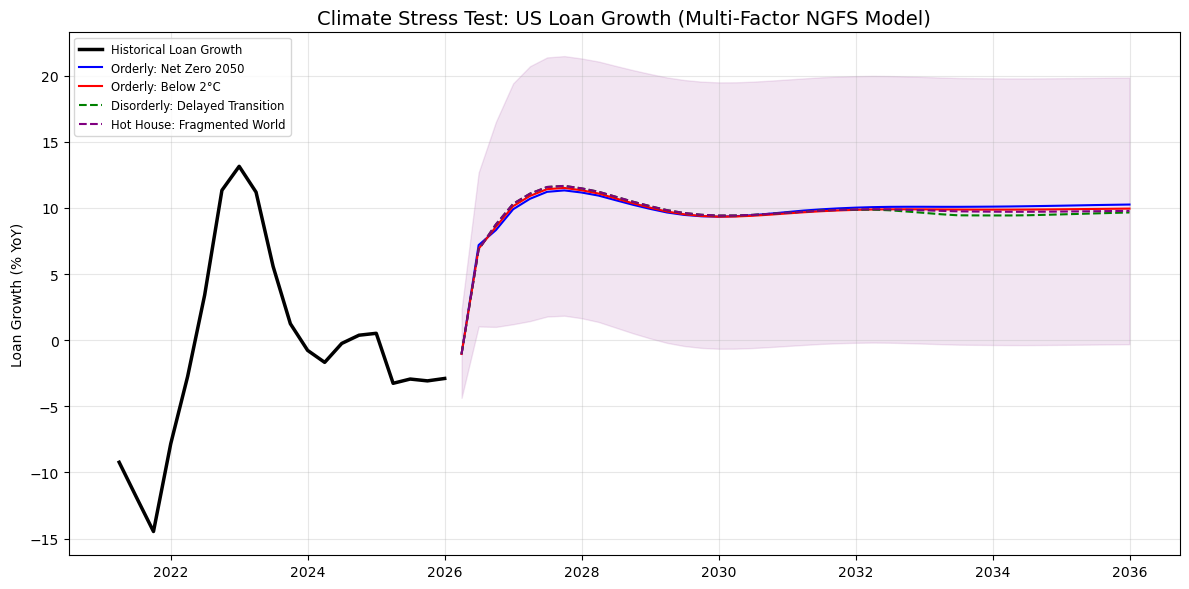

In [71]:
## FINAL MODEL: MULTI-FACTOR NGFS CLIMATE STRESS TEST (PROPERLY TRAINED)
##USE THIS MODEL!!! 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# Load ALL required data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')
df_rates = clean_fred_data('FEDFUNDS.csv', 'Rates')

# ---------------------------------------------------------
# 2. MERGE + TARGET VARIABLE
# ---------------------------------------------------------
df_history = pd.concat([
    df_loans, df_unemp, df_gdp, df_rates
], axis=1).dropna()

df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# ---------------------------------------------------------
# 3. SMOOTH COVID
# ---------------------------------------------------------
shock_start, shock_end = '2020-03-01', '2021-06-30'

for col in ['Loan_Growth', 'Unemployment_Rate']:
    df_history.loc[shock_start:shock_end, col] = np.nan
    df_history[col] = df_history[col].interpolate(method='linear')

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (CRITICAL UPGRADE)
# ---------------------------------------------------------
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)
df_history['GDP_Lag1'] = df_history['GDP'].shift(1)
df_history['Rates_Lag1'] = df_history['Rates'].shift(1)

df_train = df_history.dropna()

# ---------------------------------------------------------
# 5. TRAIN MODEL (NOW ACTUALLY MULTI-FACTOR)
# ---------------------------------------------------------
y = df_train['Loan_Growth']

X = df_train[['Unemployment_Lag2', 'GDP_Lag1', 'Rates_Lag1']]

model = ARIMA(
    y,
    exog=X,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 0, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 6. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]
last_gdp = df_history['GDP'].iloc[-1]
last_rates = df_history['Rates'].iloc[-1]

# ---------------------------------------------------------
# 7. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 8. BUILD MULTI-FACTOR EXOG 
# ---------------------------------------------------------
def build_ngfs_exog_multi(scenario):

    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    gdp_series = get_ngfs_series(scenario, "Gross Domestic Product")
    rate_series = get_ngfs_series(scenario, "Central bank")

    # Align forecast horizon
    unemp_shock = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    gdp_series = gdp_series.loc[forecast_dates[0]:].head(forecast_steps)
    rate_series = rate_series.loc[forecast_dates[0]:].head(forecast_steps)

    # Anchor unemployment (shock-based)
    unemp_future = last_unemp + unemp_shock

    # GDP & Rates: assume levels already (NGFS provides levels or indexed paths)
    future = pd.DataFrame({
        'Unemployment_Rate': unemp_future.values,
        'GDP': gdp_series.values,
        'Rates': rate_series.values
    }, index=forecast_dates)

    # Combine with history for lagging
    full = pd.concat([df_history[['Unemployment_Rate','GDP','Rates']], future])

    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag2'] = full['Unemployment_Rate'].shift(2).loc[forecast_dates]
    X_f['GDP_Lag1'] = full['GDP'].shift(1).loc[forecast_dates]
    X_f['Rates_Lag1'] = full['Rates'].shift(1).loc[forecast_dates]

    return X_f

# ---------------------------------------------------------
# 9. RUN ALL SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

results = {}

for key in scenarios:
    X_future = build_ngfs_exog_multi(key)
    results[key] = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

# ---------------------------------------------------------
# 10. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Loan_Growth'][-20:],
    label='Historical Loan Growth',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in results:
    plt.plot(
        forecast_dates,
        results[key].predicted_mean,
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

# Confidence interval (worst case)
conf = results["Fragmented World"].conf_int()
plt.fill_between(
    forecast_dates,
    conf.iloc[:, 0],
    conf.iloc[:, 1],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: US Loan Growth (Multi-Factor NGFS Model)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# print model summary
print(model_fit.summary())


                                    SARIMAX Results                                     
Dep. Variable:                      Loan_Growth   No. Observations:                  282
Model:             ARIMA(2, 0, 2)x(1, 0, [], 4)   Log Likelihood                -548.919
Date:                          Wed, 25 Mar 2026   AIC                           1117.839
Time:                                  19:12:50   BIC                           1154.258
Sample:                              09-30-1955   HQIC                          1132.443
                                   - 12-31-2025                                         
Covariance Type:                            opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                15.8776      2.325      6.830      0.000      11.321      20.434
Unemployment_Lag2    -1.3751  

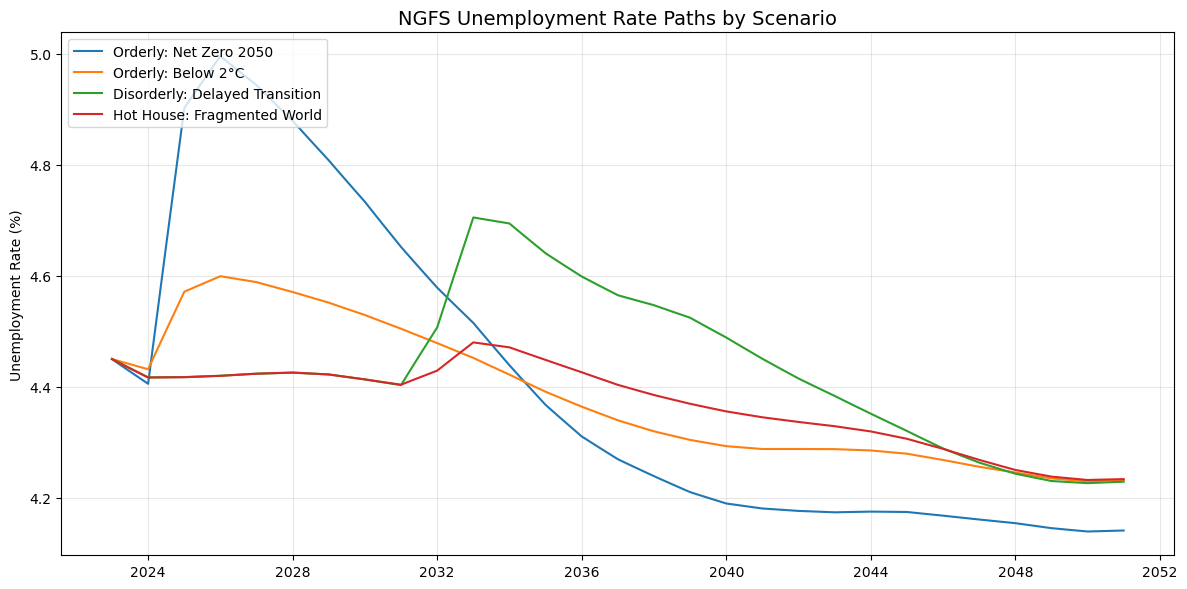

In [66]:
## plot the unemployment rate paths for each scenario to verify they are different and make sense
plt.figure(figsize=(12, 6))
for key in scenarios:
    unemp_series = get_ngfs_series(key, "Unemployment")
    plt.plot(unemp_series.index, last_unemp + unemp_series.values, label=scenarios[key])
plt.title('NGFS Unemployment Rate Paths by Scenario', fontsize=14)
plt.ylabel('Unemployment Rate (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 25, Mar, 2026
Time:                     19:06:54
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.78357
Nobs:                     278.000    HQIC:                   8.25223
Log likelihood:          -2607.44    FPE:                    2688.81
AIC:                      7.89624    Det(Omega_mle):         2120.56
--------------------------------------------------------------------
Results for equation Loan_Growth
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        2.256478         0.691427            3.264           0.001
L1.Loan_Growth               1.168518         0.057539           20.308           0.000
L1.Unemployment_Rate      

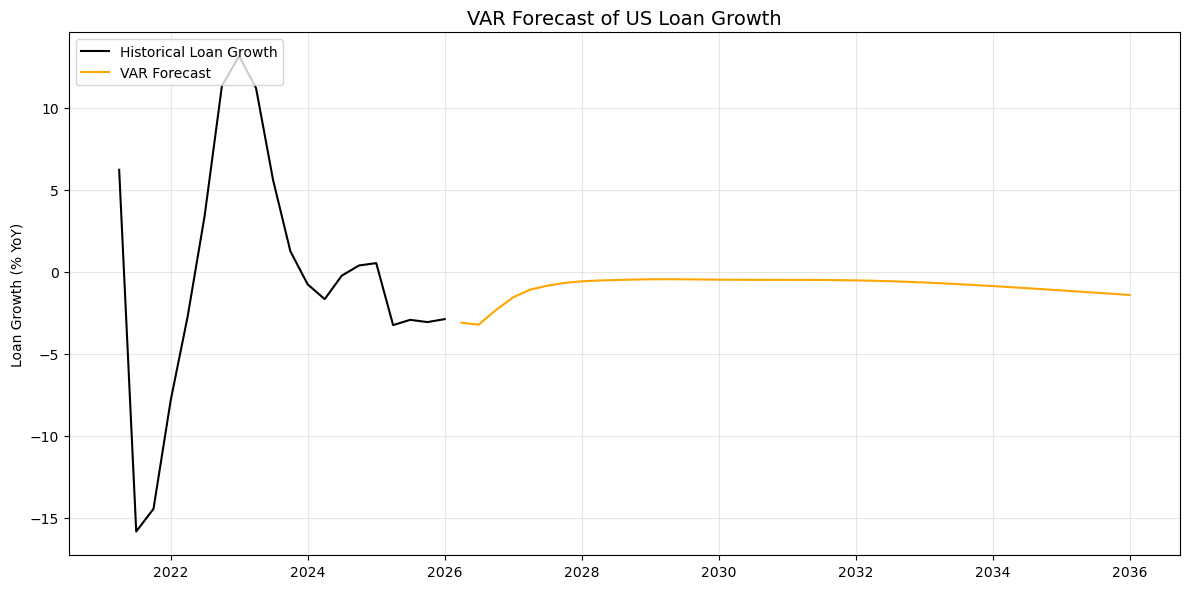

In [67]:
## var model
from statsmodels.tsa.api import VAR
# Prepare data for VAR
var_data = df_history[['Loan_Growth', 'Unemployment_Rate', 'GDP', 'Rates']].dropna()
# Fit VAR model
model_var = VAR(var_data)
results_var = model_var.fit(maxlags=4, ic='aic')
print(results_var.summary())
# Forecast with VAR
lag_order = results_var.k_ar
forecast_input = var_data.values[-lag_order:]
forecast_var = results_var.forecast(y=forecast_input, steps=forecast_steps)
# Convert forecast to DataFrame
forecast_var_df = pd.DataFrame(forecast_var, index=forecast_dates, columns=var_data.columns)
# Plot VAR forecasts
plt.figure(figsize=(12, 6))
plt.plot(var_data.index[-20:], var_data['Loan_Growth'][-20:], label='Historical Loan Growth', color='black')
plt.plot(forecast_var_df.index, forecast_var_df['Loan_Growth'], label='VAR Forecast', color='orange')
plt.title('VAR Forecast of US Loan Growth', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
## VAR model results
print(results_var.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 25, Mar, 2026
Time:                     19:07:04
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.78357
Nobs:                     278.000    HQIC:                   8.25223
Log likelihood:          -2607.44    FPE:                    2688.81
AIC:                      7.89624    Det(Omega_mle):         2120.56
--------------------------------------------------------------------
Results for equation Loan_Growth
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        2.256478         0.691427            3.264           0.001
L1.Loan_Growth               1.168518         0.057539           20.308           0.000
L1.Unemployment_Rate      

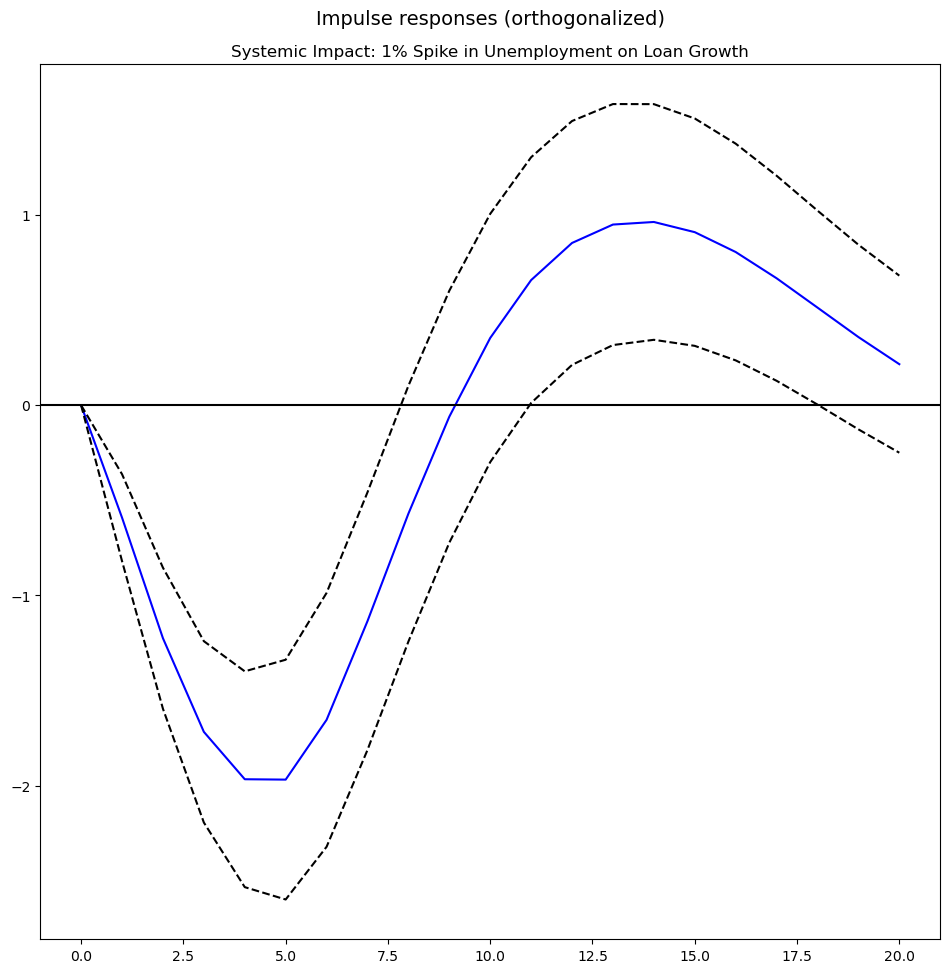

In [69]:
# Create an Impulse Response Function (IRF)
irf = results_var.irf(20) # Look at 20 quarters (5 years)

# Plot the impact of an Unemployment Shock on Loan Growth
irf.plot(impulse='Unemployment_Rate', response='Loan_Growth', orth=True)
plt.title('Systemic Impact: 1% Spike in Unemployment on Loan Growth')
plt.show()

In [70]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                      Loan_Growth   No. Observations:                  282
Model:             ARIMA(2, 0, 2)x(1, 0, [], 4)   Log Likelihood                -670.933
Date:                          Wed, 25 Mar 2026   AIC                           1361.866
Time:                                  19:07:27   BIC                           1398.285
Sample:                              09-30-1955   HQIC                          1376.470
                                   - 12-31-2025                                         
Covariance Type:                            opg                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                16.7854      4.472      3.753      0.000       8.020      25.551
Unemployment_Lag2    -1.5855      0.380     -4.167      0.000      -2.331      -0.840
GDP_Lag1             -0.0004      0.000     -1.333      0.182      -0.001       0.000
Rates_Lag1            0.5701      0.100      5.699      0.000       0.374       0.766
ar.L1                 1.4461      0.185      7.802      0.000       1.083       1.809
ar.L2                -0.5594      0.170     -3.287      0.001      -0.893      -0.226
ma.L1                -0.1655      0.195     -0.849      0.396      -0.548       0.217
ma.L2                 0.0144      0.093      0.154      0.878      -0.169       0.197
ar.S.L4               0.4170      0.036     11.561      0.000       0.346       0.488
sigma2                5.1100      0.206     24.830      0.000       4.707       5.513
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):              3780.75
Prob(Q):                              0.61   Prob(JB):                         0.00
Heteroskedasticity (H):               2.90   Skew:                            -1.74
Prob(H) (two-sided):                  0.00   Kurtosis:                        20.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
## 9. EVALUATE SCENARIO DIFFERENCES
# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Date': pred_delayed.index,
    'Delayed_Transition': pred_delayed.values,
    'Below_2C': pred_stress.values,
    'Net_Zero_2050': p_nz.values,
    'Fragmented_World': pred_fragmented.values
})
# Calculate differences between scenarios
summary_df['Delayed_vs_2C'] = summary_df['Delayed_Transition'] - summary_df['Below_2C']
summary_df['Delayed_vs_NZ'] = summary_df['Delayed_Transition'] - summary_df['Net_Zero_2050']
summary_df['2C_vs_NZ'] = summary_df['Below_2C'] - summary_df['Net_Zero_2050']
summary_df['Fragmented_vs_Delayed'] = summary_df['Fragmented_World'] - summary_df['Delayed_Transition']
summary_df['Fragmented_vs_2C'] = summary_df['Fragmented_World'] - summary_df['Below_2C']
summary_df['Fragmented_vs_NZ'] = summary_df['Fragmented_World'] - summary_df['Net_Zero_2050']
print(summary_df.head())


        Date  Delayed_Transition   Below_2C  Net_Zero_2050  Fragmented_World  \
0 2026-06-30            5.863732   5.863732       5.863732          5.863732   
1 2026-09-30            8.954640   8.954640       8.954640          8.954640   
2 2026-12-31           11.271489  11.107785      10.750594         11.271581   
3 2027-03-31           11.579355  11.419049      11.071772         11.579376   
4 2027-06-30           11.888621  11.731713      11.394349         11.888571   

   Delayed_vs_2C  Delayed_vs_NZ  2C_vs_NZ  Fragmented_vs_Delayed  \
0       0.000000       0.000000  0.000000               0.000000   
1       0.000000       0.000000  0.000000               0.000000   
2       0.163703       0.520895  0.357191               0.000092   
3       0.160306       0.507583  0.347278               0.000021   
4       0.156908       0.494272  0.337364              -0.000050   

   Fragmented_vs_2C  Fragmented_vs_NZ  
0          0.000000          0.000000  
1          0.000000          0

In [ ]:
## model validation using backtesting on historical data
# Backtesting with Walk-Forward Validation  
from sklearn.metrics import mean_absolute_error
# We will use the last 5 years for backtesting
backtest_start = df_train.index[-20]  # Last 5 years (20 quarters)
# Store predictions and actuals
backtest_predictions = []
backtest_actuals = []
# Walk-forward loop
for i in range(20, len(df_train)):
    # Train on data up to the current point
    train_data = df_train.iloc[:i]
    y_train = train_data['Loan_Growth']
    X_train = train_data[['Unemployment_Lag2']]
    
    # Fit model
    model_bt = ARIMA(y_train, exog=X_train, order=(2, 0, 2))
    model_fit_bt = model_bt.fit()
    
    # Predict the next quarter
    X_next = df_train.iloc[i][['Unemployment_Lag2']].values.reshape(1, -1)
    pred_next = model_fit_bt.get_forecast(steps=1, exog=X_next).predicted_mean[0]
    
    # Store prediction and actual
    backtest_predictions.append(pred_next)
    backtest_actuals.append(df_train['Loan_Growth'].iloc[i])
# Calculate MAE
mae = mean_absolute_error(backtest_actuals, backtest_predictions)
print(f"Backtesting MAE: {mae:.4f}")
# calculat relative error
relative_errors = np.abs(np.array(backtest_predictions) - np.array(backtest_actuals)) / np.abs(backtest_actuals)
average_relative_error = np.mean(relative_errors)
print(f"Average Relative Error: {average_relative_error:.4f}")

Backtesting MAE: 1.5124
Average Relative Error: 0.3854


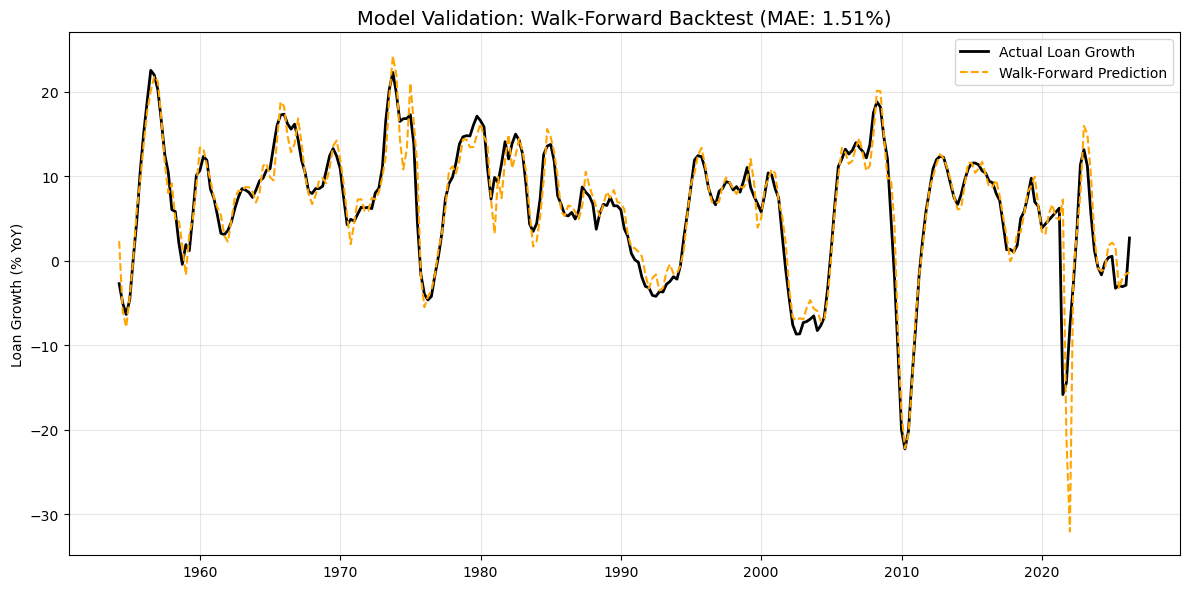

In [ ]:
# Create a series for the dates corresponding to the backtest
# Since your loop starts at index 20, the dates start there too
backtest_dates = df_train.index[20:]

plt.figure(figsize=(12, 6))

# Plot Actuals
plt.plot(backtest_dates, backtest_actuals, label='Actual Loan Growth', color='black', linewidth=2)

# Plot Predictions
plt.plot(backtest_dates, backtest_predictions, label='Walk-Forward Prediction', color='orange', linestyle='--', linewidth=1.5)

plt.title(f'Model Validation: Walk-Forward Backtest (MAE: {mae:.2f}%)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

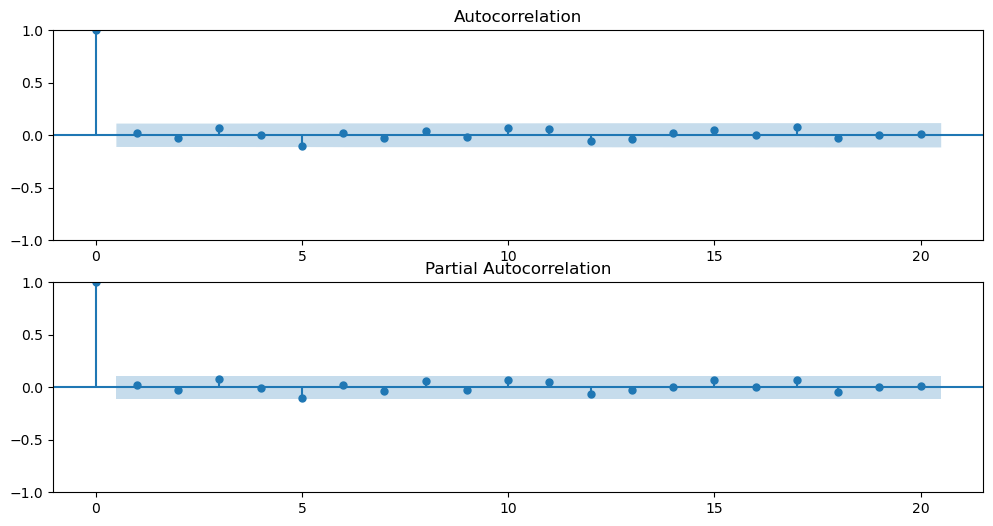

In [ ]:
## pull out autocorrelation and partial autocorrelation plots to check for remaining patterns in the residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.subplot(212)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.show()

## Ignore Below

In [ ]:
physicaldata = pd.read_excel('/Users/geoffpoint-du-jour/Downloads/Forecasting/ECON-522-Forecasting-Project/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx')

In [ ]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [ ]:
ngfs_quarterly.head()

,Below 2°C_Carbon pricing ; $ per Tn CO2(combined),Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined),Below 2°C_Coal price ; US$ per barrel (equiv)(combined),Below 2°C_Consumption (private)(combined),Below 2°C_Domestic demand(combined),Below 2°C_Effective exchange rate(combined),Below 2°C_Energy consumption (total) ; MnToe(combined),Below 2°C_Equity prices(combined),Below 2°C_Exports (goods and services)(combined),Below 2°C_Gas price ; US$ per barrel (equiv)(combined),...,Net Zero 2050_Productivity (output per hour worked); US$ Bn(combined),Net Zero 2050_Quarterly consumption of coal ; MnToe(combined),Net Zero 2050_Quarterly consumption of gas ; MnToe(combined),Net Zero 2050_Quarterly consumption of non-carbon ; MnToe(combined),Net Zero 2050_Quarterly consumption of oil ; MnToe(combined),Net Zero 2050_Real personal disposable income(combined),Net Zero 2050_Revenue from CB or BCA tax; US$ Bn(combined),Net Zero 2050_Trend output for capacity utilisation(combined),Net Zero 2050_Unemployment rate ; %(combined),Net Zero 2050_Volume energy use as a share of GDP ; Bn US$(PPP)(combined)
Year,,,,,,,,,,,,,,,,,,,,,
2022-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-03-31,1.908148,0.090281,1.003075,-0.339661,-0.343849,-0.146234,-0.164327,-0.939242,0.048806,0.283405,...,-0.359681,-0.879059,-0.340875,0.363506,-0.441451,-0.435026,68.850639,-0.318989,-0.011146,-0.191943
2023-06-30,3.816295,0.180562,2.006149,-0.679322,-0.687699,-0.292468,-0.328655,-1.878484,0.097611,0.566809,...,-0.719362,-1.758118,-0.681750,0.727011,-0.882901,-0.870052,137.701278,-0.637978,-0.022293,-0.383887
2023-09-30,5.724443,0.270843,3.009224,-1.018983,-1.031548,-0.438701,-0.492982,-2.817726,0.146417,0.850214,...,-1.079044,-2.637178,-1.022625,1.090517,-1.324352,-1.305078,206.551917,-0.956967,-0.033439,-0.575830
2023-12-31,7.632591,0.361124,4.012299,-1.358644,-1.375397,-0.584935,-0.657310,-3.756967,0.195222,1.133619,...,-1.438725,-3.516237,-1.363500,1.454023,-1.765802,-1.740103,275.402556,-1.275956,-0.044585,-0.767774


In [ ]:
## implement ngfs_quarterly into our forecasting model as additional features to see if they improve the forecasts
# Merge NGFS data with historical data
df_model = df_history.merge(ngfs_quarterly, left_index=True, right_index=True, how='left')
# We will use the same target (Loan Growth) but now with additional features from NGFS
# Define target and features
target = 'Loan_Growth'
features = ['Unemployment_Lag2'] + [col for col in ngfs_quarterly.columns if 'combined' in col]
# drop na
df_model = df_model.dropna(subset=[target] + features)
# Train/Test Split
from sklearn.model_selection import train_test_split
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Train ARIMA with exogenous variables (NGFS features)
model_ngfs = ARIMA(y_train, exog=X_train, order=(2, 0, 2))
model_fit_ngfs = model_ngfs.fit()
print(model_fit_ngfs.summary())
# Forecast on test set
forecast_ngfs = model_fit_ngfs.get_forecast(steps=len(X_test), exog=X_test)
pred_ngfs = forecast_ngfs.predicted_mean
# Evaluate
from sklearn.metrics import mean_absolute_error
mae_ngfs = mean_absolute_error(y_test, pred_ngfs)
print(f"MAE with NGFS features: {mae_ngfs:.4f}")
# Compare with original model (without NGFS features)
model_original = ARIMA(y_train, exog=X_train[['Unemployment_Lag2']], order=(2, 0, 2))
model_fit_original = model_original.fit()
forecast_original = model_fit_original.get_forecast(steps=len(X_test), exog=X_test[['Unemployment_Lag2']])
pred_original = forecast_original.predicted_mean
mae_original = mean_absolute_error(y_test, pred_original)
print(f"MAE without NGFS features: {mae_original:.4f}")


                               SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                   11
Model:                 ARIMA(2, 0, 2)   Log Likelihood                  -9.739
Date:                Wed, 18 Mar 2026   AIC                            481.479
Time:                        23:30:48   BIC                            573.393
Sample:                    12-31-2022   HQIC                           423.540
                         - 06-30-2025                                         
Covariance Type:                  opg                                         
                                                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
const     

In [ ]:
# ---------------------------------------------------------
# 6. LOAD & PROCESS NGFS (WIDE FORMAT CONVERSION)
# ---------------------------------------------------------
print("\nProcessing NGFS Scenarios (Wide Format)...")

# ==============================================================================
# A. CONFIGURATION (Updated for NiGEM/NGFS Structure)
# ==============================================================================
# Point to your NiGEM or Downscaled NGFS CSV
file_path = 'NiGEM_data.xlsx'

# Typical NGFS strings - update these if your specific file uses different ones
TARGET_REGION = 'United States' 

# Variables often appear as 'Unemployment Rate' or 'Price|Consumer Price Index'
VAR_UNEMP = 'Unemployment Rate' 
VAR_INFL  = 'Inflation Rate'    

# Scenarios often include a prefix like 'NGFS Phase 4' or 'Disorderly'
SCENARIO_DELAYED = 'Delayed transition'
SCENARIO_NETZERO = 'Net Zero 2050'
# ==============================================================================

try:
    # 1. Load Raw Data with Latin-1 encoding to fix UnicodeDecodeError
    df_raw = pd.read_csv(file_path, encoding='latin-1')
    print(f"✅ Loaded {file_path}. Rows: {len(df_raw)}")
    
    # Strip whitespace from string columns to prevent matching errors
    string_cols = ['Region', 'Variable', 'Scenario']
    for col in string_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].astype(str).str.strip()

    # 2. Filter for Region
    df_reg = df_raw[df_raw['Region'] == TARGET_REGION].copy()
    if df_reg.empty:
        print(f"❌ ERROR: No data found for Region '{TARGET_REGION}'.")
        print("Available Regions:", df_raw['Region'].unique()[:5])
        raise ValueError("Region Not Found")

    # 3. Flexible Extract Function
    def extract_scenario_series(df, scenario_name, var_name):
        # We use str.contains in case there are prefixes like 'Phase 4 | Delayed transition'
        mask = (df['Scenario'].str.contains(scenario_name, case=False, na=False)) & \
               (df['Variable'].str.contains(var_name, case=False, na=False))
        row = df[mask]
        
        if row.empty:
            return None
        
        # Identify year columns (e.g., '2022', '2023'...)
        year_cols = [c for c in df.columns if c.isdigit()]
        ts_data = row[year_cols].T
        ts_data.columns = ['Value']
        ts_data.index.name = 'Year'
        return pd.to_numeric(ts_data['Value'], errors='coerce')

    # 4. Extract Data
    s_unemp_delayed = extract_scenario_series(df_reg, SCENARIO_DELAYED, VAR_UNEMP)
    s_infl_delayed  = extract_scenario_series(df_reg, SCENARIO_DELAYED, VAR_INFL)
    s_unemp_netzero = extract_scenario_series(df_reg, SCENARIO_NETZERO, VAR_UNEMP)
    s_infl_netzero  = extract_scenario_series(df_reg, SCENARIO_NETZERO, VAR_INFL)

    # 5. Build cleaned Scenario DataFrame
    df_ngfs_clean = pd.DataFrame({
        'Unemp_Delayed': s_unemp_delayed,
        'Infl_Delayed': s_infl_delayed,
        'Unemp_NetZero': s_unemp_netzero,
        'Infl_NetZero': s_infl_netzero
    }).dropna()

    if df_ngfs_clean.empty:
        raise ValueError("Could not find matching Scenarios/Variables. Check debug info below.")

    # 6. Convert Index to Datetime & Resample to Quarterly
    df_ngfs_clean.index = pd.to_datetime(df_ngfs_clean.index.astype(str) + '-12-31')
    
    # Quarterly interpolation
    future_dates = pd.date_range(start=df_train.index[-1], periods=21, freq='QE')[1:]
    df_ngfs_q = df_ngfs_clean.resample('QE').asfreq().interpolate(method='linear')
    df_ngfs_future = df_ngfs_q.reindex(future_dates).fillna(method='ffill')
    
    print("✅ NGFS Data successfully prepared.")
    print(df_ngfs_future.head())

except Exception as e:
    print(f"❌ Error: {e}")
    if 'df_raw' in locals():
        print("\n--- DEBUG INFO ---")
        print("Variables in CSV:", df_raw['Variable'].unique()[:10])
        print("Scenarios in CSV:", df_raw['Scenario'].unique()[:5])


Processing NGFS Scenarios (Wide Format)...
❌ Error: Error tokenizing data. C error: Expected 2 fields in line 7, saw 4



In [ ]:
X_future_delayed = pd.DataFrame(index=future_dates)
X_future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                    df_history['Unemployment_Rate'].iloc[-1]+0.5,
                                                    steps)

# Stress Scenario: Below 2°C Transition Shock (high stress)
X_future_stress = pd.DataFrame(index=future_dates)
X_future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                   df_history['Unemployment_Rate'].iloc[-1]+4.0,
                                                   steps)

In [ ]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

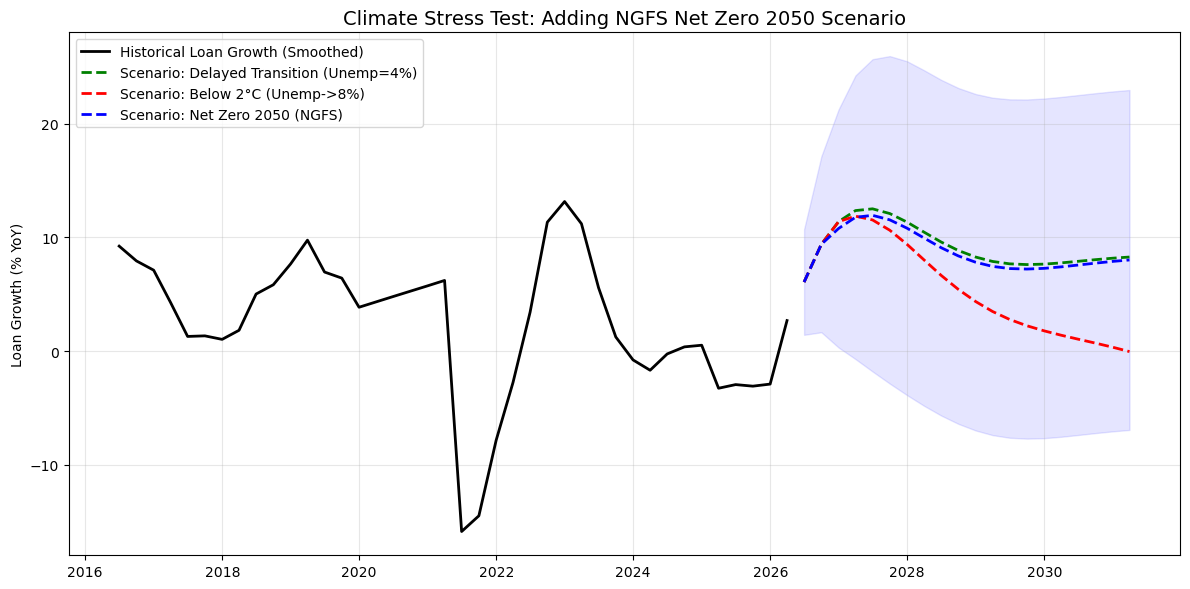

In [ ]:
# Define the forecast window 
forecast_steps = 20 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='Q')[1:]

# Extract the NGFS Unemployment column for Net Zero 2050
# Reminder: NiGEM values are SHOCKS (e.g., +1.5 means 1.5% higher than baseline)
nz_unemp_shock = ngfs_quarterly.loc[forecast_dates[0]:, 'Net Zero 2050_Unemployment rate ; %(combined)'].head(forecast_steps)
# Extract the NGFS Unemployment column for Delayed Transition
delayed_unemp_shock = ngfs_quarterly.loc[forecast_dates[0]:, 'Delayed transition_Unemployment rate ; %(combined)'].head(forecast_steps)



# Anchor the shock to the last historical FRED data point
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]
future_unemp_path = last_actual_unemp + nz_unemp_shock
# For Delayed Transition scenario
future_unemp_path_delayed = last_actual_unemp + delayed_unemp_shock


# Combine history + future to calculate rolling features without a 'break' at the start
full_series = pd.concat([df_history['Unemployment_Rate'], future_unemp_path,])
full_series_delayed = pd.concat([df_history['Unemployment_Rate'], future_unemp_path_delayed])
# Create the future Exogenous DataFrame
X_future_nz = pd.DataFrame(index=forecast_dates)
X_future_nz['Unemployment_Lag2'] = full_series.shift(2).loc[forecast_dates]




# Generate the forecast
# steps must match the number of rows in X_future_nz
nz_forecast = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
pred_delayed = forecast_delayed.predicted_mean 

# Extract the results
p_nz = nz_forecast.predicted_mean
conf_nz = nz_forecast.conf_int()
# Plotting
plt.figure(figsize=(12, 6))
# Historical Loan Growth
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)
# Delayed Transition Scenario
plt.plot(pred_delayed.index, pred_delayed, label='Scenario: Delayed Transition (Unemp=4%)', color='green', linestyle='--', linewidth=2)
# Below 2°C Transition Shock
plt.plot(pred_stress.index, pred_stress, label='Scenario: Below 2°C (Unemp->8%)', color='red', linestyle='--', linewidth=2)
# Net Zero 2050 Scenario (NGFS)
plt.plot(p_nz.index, p_nz, label='Scenario: Net Zero 2050 (NGFS)', color='blue', linestyle='--', linewidth=2)
# Confidence Interval for Net Zero Scenario
plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)
plt.title('Climate Stress Test: Adding NGFS Net Zero 2050 Scenario', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
